In [1]:
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.transforms import ToTensor,Compose,RandomHorizontalFlip, Normalize, ToPILImage, RandomRotation, ColorJitter
from torchvision.utils import make_grid
import torchvision.transforms as transforms
import torchvision
import torch.optim.lr_scheduler as lr_scheduler

from tools.plot import show_images, plot_metrics, plot_cifar_distribution


## SoftMax


In [2]:
def softmax(x, dim=1):
    """
    手动实现 Softmax 函数
    
    Args:
        x (torch.Tensor): 输入张量，形状例如 (batch_size, num_classes)
        dim (int): 进行 Softmax 操作的维度，默认为 1（类别维度）
    
    Returns:
        torch.Tensor: Softmax 概率分布，形状与 x 相同，且沿指定维度总和为 1
    """
    # TODO: 实现 Softmax 函数
    # 1. 对输入 x 减去其在指定维度上的最大值（防止溢出）
    # 2. 计算指数函数 torch.exp
    # 3. 计算指数和（沿指定维度）
    # 4. 返回归一化的概率

    return x


batch_size = 5
num_classes = 3

# 随机生成模型的预测结果 (logits)，目标标签
predictions = torch.randn(batch_size, num_classes)  # [batch_size, num_classes]
targets = torch.tensor([0, 2, 1, 0, 1])  # 目标标签, [batch_size]


# 1. Softmax 对比
manual_softmax = softmax(predictions, dim=-1)
official_softmax = F.softmax(predictions, dim=-1)

# 打印 Softmax 对比结果
print("Softmax Comparison:")
print(f"Manual Softmax: {manual_softmax}")
print(f"Official Softmax: {official_softmax}")
print(f"Softmax Close? {torch.allclose(manual_softmax, official_softmax, atol=1e-6)}\n")

Softmax Comparison:
Manual Softmax: tensor([[0.1848, 0.7897, 0.0255],
        [0.0478, 0.3340, 0.6182],
        [0.5927, 0.1868, 0.2206],
        [0.3455, 0.4226, 0.2319],
        [0.5760, 0.3216, 0.1024]])
Official Softmax: tensor([[0.1848, 0.7897, 0.0255],
        [0.0478, 0.3340, 0.6182],
        [0.5927, 0.1868, 0.2206],
        [0.3455, 0.4226, 0.2319],
        [0.5760, 0.3216, 0.1024]])
Softmax Close? True



# Cross Entropy Loss

In [3]:
# 手动实现 CrossEntropy
def cross_entropy(predictions, targets):
    """
    手动实现 Cross Entropy 损失
    
    Args:
        predictions (torch.Tensor): 模型预测值 (logits)，形状为 (batch_size, num_classes)
        targets (torch.Tensor): 真实标签，形状为 (batch_size,)，值为类别索引
        
    Returns:
        torch.Tensor: 交叉熵损失的平均值（标量）
    """
    # TODO: 实现交叉熵损失
    # 1. 使用 torch.softmax 将 predictions 转换为概率分布 (沿 dim=1)
    # 2. 将 targets 转换为 one-hot 编码，形状与 predictions 相同
    # 3. 计算 log(probs)
    # 4. 计算交叉熵损失：-mean(sum(one_hot * log(probs)))

    return loss

# 官方实现的 CrossEntropyLoss (torch.nn.CrossEntropyLoss)
cross_entropy_loss_fn = nn.CrossEntropyLoss()

batch_size = 5
num_classes = 3

# 随机生成模型的预测结果 (logits)，目标标签
predictions = torch.randn(batch_size, num_classes)  # [batch_size, num_classes]
targets = torch.tensor([0, 2, 1, 0, 1])  # 目标标签, [batch_size]


# 2. CrossEntropy 对比
manual_loss = cross_entropy(predictions, targets)
official_loss = cross_entropy_loss_fn(predictions, targets)

# 打印 CrossEntropy 对比结果
print("CrossEntropy Comparison:")
print(f"Manual CrossEntropy Loss: {manual_loss.item():.6f}")
print(f"Official CrossEntropy Loss: {official_loss.item():.6f}")
print(f"CrossEntropy Close? {torch.isclose(manual_loss, official_loss, atol=1e-6)}")

CrossEntropy Comparison:
Manual CrossEntropy Loss: 1.475054
Official CrossEntropy Loss: 1.475054
CrossEntropy Close? True


## Activation Functions

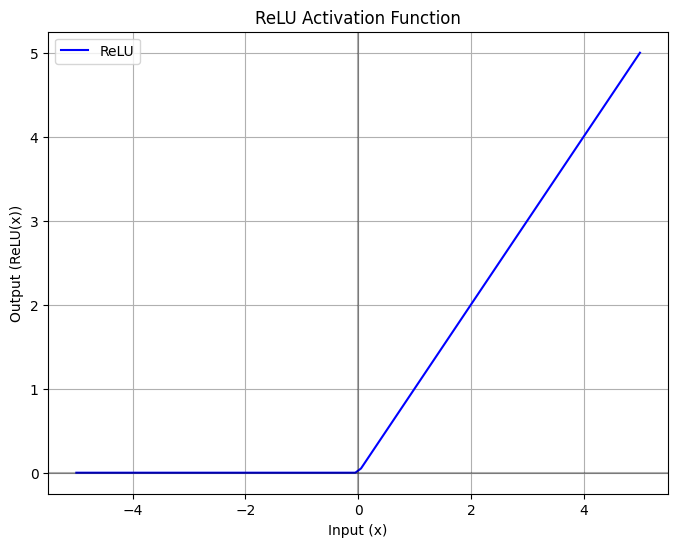

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ReLU 激活函数
def relu(x):
    """
    ReLU 激活函数：如果 x > 0，返回 x；否则返回 0。
    
    Args:
        x (float or np.ndarray): 输入值
    
    Returns:
        float or np.ndarray: ReLU 后的输出
    """
    return np.maximum(0, x)

# 生成数据用于绘图
x = np.linspace(-5, 5, 100)  # 生成 -5 到 5 的 100 个点
y = relu(x)  # 计算 ReLU 输出

# 绘制 ReLU 函数图形
plt.figure(figsize=(8, 6))
plt.plot(x, y, 'b-', label='ReLU')
plt.grid(True)
plt.title('ReLU Activation Function')
plt.xlabel('Input (x)')
plt.ylabel('Output (ReLU(x))')
plt.legend()
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)  # 添加 x 轴线
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)  # 添加 y 轴线
plt.show()

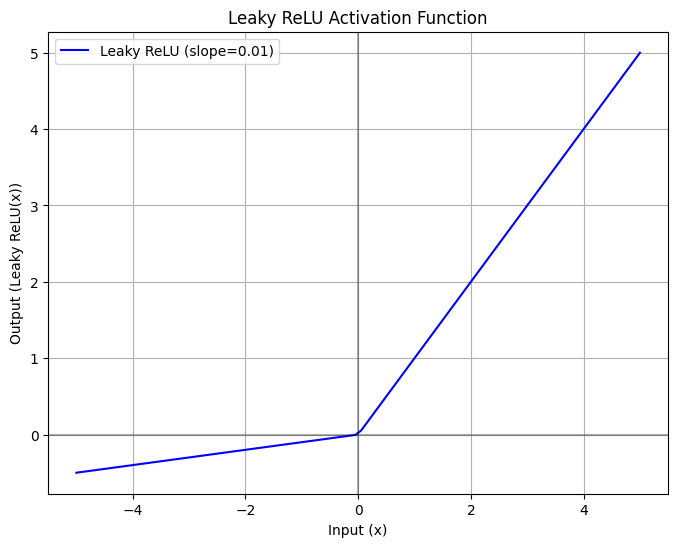

In [5]:
# Hand-written Leaky ReLU activation function (simple version)
def leaky_relu(x, slope=0.1):
    """
    Custom Leaky ReLU activation function:
    If x > 0, return x; otherwise, return x multiplied by a small slope (default 0.01).
    
    Parameters:
        x: Input number or list of numbers (can use a numpy array)
        slope: The slope for negative values (default 0.01, meaning negative parts will have a slight tilt, not zero)
    
    Returns:
        Output value (after applying Leaky ReLU)
    """
    # TODO: 实现 Leaky ReLU
    # 1. 如果 x 是标量 (int 或 float):
    #    - 如果 x > 0，返回 x
    #    - 否则，返回 slope * x
    # 2. 如果 x 是 NumPy 数组:
    #    - 创建一个与 x 形状相同的零数组
    #    - 对每个元素应用 Leaky ReLU 规则
    #    - 返回结果数组

    return result

# Generate data for plotting (simple version)
x = np.linspace(-5, 5, 100)  # Create 100 points from -5 to 5
y = leaky_relu(x, slope=0.1)  # Process these points with Leaky ReLU

# Set Matplotlib to support English (no Chinese, so no font warnings)
plt.rcParams['font.family'] = 'sans-serif'  # Use sans-serif font
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # Default font for English

# Plot the graph (simple version)
plt.figure(figsize=(8, 6))  # Set figure size
plt.plot(x, y, 'b-', label='Leaky ReLU (slope=0.01)')  # Plot the curve, blue solid line
plt.grid(True)  # Add a grid for easier reading
plt.title('Leaky ReLU Activation Function')  # Title
plt.xlabel('Input (x)')  # X-axis label
plt.ylabel('Output (Leaky ReLU(x))')  # Y-axis label
plt.legend()  # Show legend
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)  # Add x-axis line
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)  # Add y-axis line
plt.show()  # Display the image